## Problem Statement

To collect restaurant data through web scraping from the EazyDiner platform and perform exploratory data analysis to understand restaurant distribution, pricing trends, customer ratings, and cuisine preferences across cities and regions.

### Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

### Load the restaurant dataset scraped from th EazyDiner website

In [2]:
data = pd.read_csv('eazydiner_restaurants.csv')

In [3]:
# Display the first five rows to understand the dataset structure

data.head()

,restaurant_name,city,location,cuisine,cost_for_two,rating,restaurant_url,region
0,Desi Villagio,Delhi NCR,"Connaught Place (CP), Central Delhi",Indian,₹1300,4.1,https://www.eazydiner.comhttps://www.eazydiner...,North India
1,Cafe Out of the Box Courtyard,Delhi NCR,"Connaught Place (CP), Central Delhi",Multicuisine,₹1200,3.9,https://www.eazydiner.comhttps://www.eazydiner...,North India
2,Hard Rock Cafe,Delhi NCR,"Connaught Place (CP), Central Delhi",Multicuisine,₹1500,4.0,https://www.eazydiner.comhttps://www.eazydiner...,North India
3,Sakura,Delhi NCR,"The Metropolitan Hotel & Spa, New Delhi","Japanese, Sushi",₹4500,4.0,https://www.eazydiner.comhttps://www.eazydiner...,North India
4,Dr. Zombie,Delhi NCR,"Connaught Place (CP), Central Delhi","Italian, Cocktail Menu",₹1000,4.3,https://www.eazydiner.comhttps://www.eazydiner...,North India


In [4]:
# Get dataset information

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1077 entries, 0 to 1076
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   restaurant_name  1077 non-null   object 
 1   city             1077 non-null   object 
 2   location         1077 non-null   object 
 3   cuisine          1077 non-null   object 
 4   cost_for_two     1075 non-null   object 
 5   rating           1077 non-null   float64
 6   restaurant_url   1077 non-null   object 
 7   region           1077 non-null   object 
dtypes: float64(1), object(7)
memory usage: 67.4+ KB


In [5]:
# Generate summary statistics for numerical columns

data.describe()

,rating
count,1077.000000
mean,4.187465
std,0.604983
min,1.000000
25%,4.000000
50%,4.200000
75%,4.500000
max,5.000000


In [6]:
# Check dataset dimensions

data.shape

(1077, 8)

In [7]:
# Number of features/columns

data.shape[1]

8

In [8]:
# Number of observations/rows

data.shape[0]

1077

In [9]:
# Checks the data type of each feature/column

data.dtypes

restaurant_name     object
city                object
location            object
cuisine             object
cost_for_two        object
rating             float64
restaurant_url      object
region              object
dtype: object

The dataset contains both numerical and categorical variables, where numerical features are used for statistical analysis and categorical features for grouping. Any incorrect data types will be corrected during preprocessing.

In [10]:
# Checks the number of missing (null) values in each column

data.isnull().sum()

restaurant_name    0
city               0
location           0
cuisine            0
cost_for_two       2
rating             0
restaurant_url     0
region             0
dtype: int64

The output highlights missing values in each column, which will be handled using appropriate methods or removal based on their impact on analysis.

In [11]:
# Removing the special characters from the text columns to standardize and clean textual data

text_col = ['restaurant_name','city','location','cuisine','region']

for col in text_col:
    data[col] = data[col].str.replace(r'[^A-Za-z0-9,]', ' ',regex=True).str.strip()

Special characters were removed to standardize text data and ensure accurate grouping and analysis by avoiding formatting inconsistencies.

In [12]:
# Handling incorrect headers
# Standardize colum names by fixing spaces, casing and formatting

data.columns = (data.columns.str.strip().str.lower().str.replace(' ','_'))

Column names were standardized to ensure consistency and ease of access during analysis and coding.

In [13]:
data.head()

,restaurant_name,city,location,cuisine,cost_for_two,rating,restaurant_url,region
0,Desi Villagio,Delhi NCR,"Connaught Place CP , Central Delhi",Indian,₹1300,4.1,https://www.eazydiner.comhttps://www.eazydiner...,North India
1,Cafe Out of the Box Courtyard,Delhi NCR,"Connaught Place CP , Central Delhi",Multicuisine,₹1200,3.9,https://www.eazydiner.comhttps://www.eazydiner...,North India
2,Hard Rock Cafe,Delhi NCR,"Connaught Place CP , Central Delhi",Multicuisine,₹1500,4.0,https://www.eazydiner.comhttps://www.eazydiner...,North India
3,Sakura,Delhi NCR,"The Metropolitan Hotel Spa, New Delhi","Japanese, Sushi",₹4500,4.0,https://www.eazydiner.comhttps://www.eazydiner...,North India
4,Dr Zombie,Delhi NCR,"Connaught Place CP , Central Delhi","Italian, Cocktail Menu",₹1000,4.3,https://www.eazydiner.comhttps://www.eazydiner...,North India


In [14]:
# Fix incorrect dataformat by cleaning and converting cost_for_two to numeric type

data['cost_for_two'] = (data['cost_for_two'].str.replace('₹','',regex=False).str.replace(',','',regex=False))
data['cost_for_two'] = pd.to_numeric(data['cost_for_two'])

Currency symbols and commas were removed and the column was converted to numeric to enable accurate statistical analysis

In [15]:
# convertrating and cost_for_two columns to float for numerical analysis

data['rating'] = data['rating'].astype(float)
data['cost_for_two'] = data['cost_for_two'].astype(float)

The rating and cost columns were converted to numeric data types to support statistical analysis and visualization.

In [16]:
# Identify missing values in the dataset before applying appropriate treatment

data.isnull().sum()

restaurant_name    0
city               0
location           0
cuisine            0
cost_for_two       2
rating             0
restaurant_url     0
region             0
dtype: int64

Missing values were identified to decide the most suitable treatment methods before analysis.

In [17]:
# Impute missing values in cost_for_two using the median to handle outliers

data['cost_for_two'] = data['cost_for_two'].fillna(data['cost_for_two'].median())

Missing cost values were replaced with the median to minimize the impact of outliers.

In [18]:
# Identify outliers in cost_for_two using the Interquartile Range (IQR) method

Q1 = data['cost_for_two'].quantile(0.25)
Q3 = data['cost_for_two'].quantile(0.75)

IQR = Q3-Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

print('Lower Bound:', lower_bound)
print('Upper_bound:',upper_bound)

Lower Bound: -750.0
Upper_bound: 3650.0


The IQR method was used to identify potential outliers in cost data by defining acceptable lower and upper limits.

In [19]:
# Identify outliers in cost_for_two based on the IQR bounds

data[(data.cost_for_two<lower_bound) |(data.cost_for_two>upper_bound)]

,restaurant_name,city,location,cuisine,cost_for_two,rating,restaurant_url,region
3,Sakura,Delhi NCR,"The Metropolitan Hotel Spa, New Delhi","Japanese, Sushi",4500.0,4.0,https://www.eazydiner.comhttps://www.eazydiner...,North India
40,Eau De Monsoon,Delhi NCR,"Le Meridien, New Delhi",Modern Indian,4000.0,4.4,https://www.eazydiner.comhttps://www.eazydiner...,North India
67,Spectra,Delhi NCR,"The Leela Ambience, Gurgaon",Multicuisine,5000.0,4.4,https://www.eazydiner.comhttps://www.eazydiner...,North India
91,Spectra,Gurgaon,"The Leela Ambience, Gurgaon",Multicuisine,5000.0,4.4,https://www.eazydiner.comhttps://www.eazydiner...,North India
161,Seasonal Tastes,Gurgaon,"The Westin, Gurgaon",Multicuisine,4500.0,4.3,https://www.eazydiner.comhttps://www.eazydiner...,North India
231,SXVIII,Noida,"Radisson Blu MBD, Noida",Multicuisine,4000.0,4.3,https://www.eazydiner.comhttps://www.eazydiner...,North India
237,Made In India,Noida,"Radisson Blu MBD, Noida",North Indian,4800.0,4.4,https://www.eazydiner.comhttps://www.eazydiner...,North India
238,Rare Eastern Dining,Noida,"Radisson Blu MBD, Noida",Chinese,4000.0,4.6,https://www.eazydiner.comhttps://www.eazydiner...,North India
291,The Great Kabab Factory,Faridabad,"Radisson Blu, Faridabad","North Indian, Cocktail Menu",4000.0,5.0,https://www.eazydiner.comhttps://www.eazydiner...,North India
458,Peshawri,Jaipur,"ITC Rajputana Hotel, Jaipur",North West Frontier,4500.0,4.5,https://www.eazydiner.comhttps://www.eazydiner...,North India


Restaurants with cost values outside the effective IQR bounds were identified as potential outliers.

In [20]:
# Treat outliers in cost_for_two by capping values using effective IQR bounds

data['cost_for_two'] = data['cost_for_two'].clip(lower_bound, upper_bound)
data.head()

,restaurant_name,city,location,cuisine,cost_for_two,rating,restaurant_url,region
0,Desi Villagio,Delhi NCR,"Connaught Place CP , Central Delhi",Indian,1300.0,4.1,https://www.eazydiner.comhttps://www.eazydiner...,North India
1,Cafe Out of the Box Courtyard,Delhi NCR,"Connaught Place CP , Central Delhi",Multicuisine,1200.0,3.9,https://www.eazydiner.comhttps://www.eazydiner...,North India
2,Hard Rock Cafe,Delhi NCR,"Connaught Place CP , Central Delhi",Multicuisine,1500.0,4.0,https://www.eazydiner.comhttps://www.eazydiner...,North India
3,Sakura,Delhi NCR,"The Metropolitan Hotel Spa, New Delhi","Japanese, Sushi",3650.0,4.0,https://www.eazydiner.comhttps://www.eazydiner...,North India
4,Dr Zombie,Delhi NCR,"Connaught Place CP , Central Delhi","Italian, Cocktail Menu",1000.0,4.3,https://www.eazydiner.comhttps://www.eazydiner...,North India


Outliers were treated using the capping method, where extreme cost values were limited to the effective IQR bounds to preserve data size while reducing skewness.

In [21]:
# Merge city and region columns to create a combined location feature

data['city_region'] = data['city'] + ' - ' + data['region']
data.head()

,restaurant_name,city,location,cuisine,cost_for_two,rating,restaurant_url,region,city_region
0,Desi Villagio,Delhi NCR,"Connaught Place CP , Central Delhi",Indian,1300.0,4.1,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India
1,Cafe Out of the Box Courtyard,Delhi NCR,"Connaught Place CP , Central Delhi",Multicuisine,1200.0,3.9,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India
2,Hard Rock Cafe,Delhi NCR,"Connaught Place CP , Central Delhi",Multicuisine,1500.0,4.0,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India
3,Sakura,Delhi NCR,"The Metropolitan Hotel Spa, New Delhi","Japanese, Sushi",3650.0,4.0,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India
4,Dr Zombie,Delhi NCR,"Connaught Place CP , Central Delhi","Italian, Cocktail Menu",1000.0,4.3,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India


City and region were combined to create a unified location feature for easier grouping and analysis.

In [22]:
# Split cuisine column into primary and secondary cuisine for detailed analysis

data[['primary_cuisine','secondary_cuisine']] = (data['cuisine'].str.split(',',n=1,expand=True))
data.head()

,restaurant_name,city,location,cuisine,cost_for_two,rating,restaurant_url,region,city_region,primary_cuisine,secondary_cuisine
0,Desi Villagio,Delhi NCR,"Connaught Place CP , Central Delhi",Indian,1300.0,4.1,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India,Indian,None
1,Cafe Out of the Box Courtyard,Delhi NCR,"Connaught Place CP , Central Delhi",Multicuisine,1200.0,3.9,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India,Multicuisine,None
2,Hard Rock Cafe,Delhi NCR,"Connaught Place CP , Central Delhi",Multicuisine,1500.0,4.0,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India,Multicuisine,None
3,Sakura,Delhi NCR,"The Metropolitan Hotel Spa, New Delhi","Japanese, Sushi",3650.0,4.0,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India,Japanese,Sushi
4,Dr Zombie,Delhi NCR,"Connaught Place CP , Central Delhi","Italian, Cocktail Menu",1000.0,4.3,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India,Italian,Cocktail Menu


The cuisine column was split into primary and secondary cuisines to enable more granular analysis of food preferences.

In [23]:
# Categorize restaurants based on cost_for_two into budget segments


data['cost_category']=pd.cut(data['cost_for_two'],bins=[0,500,1000,2000,data['cost_for_two'].max()],labels=['Budget','Mid-range','Premium','Luxury'])
data.head()

,restaurant_name,city,location,cuisine,cost_for_two,rating,restaurant_url,region,city_region,primary_cuisine,secondary_cuisine,cost_category
0,Desi Villagio,Delhi NCR,"Connaught Place CP , Central Delhi",Indian,1300.0,4.1,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India,Indian,None,Premium
1,Cafe Out of the Box Courtyard,Delhi NCR,"Connaught Place CP , Central Delhi",Multicuisine,1200.0,3.9,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India,Multicuisine,None,Premium
2,Hard Rock Cafe,Delhi NCR,"Connaught Place CP , Central Delhi",Multicuisine,1500.0,4.0,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India,Multicuisine,None,Premium
3,Sakura,Delhi NCR,"The Metropolitan Hotel Spa, New Delhi","Japanese, Sushi",3650.0,4.0,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India,Japanese,Sushi,Luxury
4,Dr Zombie,Delhi NCR,"Connaught Place CP , Central Delhi","Italian, Cocktail Menu",1000.0,4.3,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India,Italian,Cocktail Menu,Mid-range


Restaurants were grouped into cost categories to simplify comparison across pricing segments.

## Univariate Analysis

### Analysis of Continuous Variables

In [24]:
# Continuous variables

# Calculate central tendency measures for the continuous variable cost_for_two

print('Means of cost for two:',data['cost_for_two'].mean())
print('Median of cost for two:',data['cost_for_two'].median())
print('Mode of cost for two:',data['cost_for_two'].mode())

Means of cost for two: 1436.9145775301763
Median of cost for two: 1300.0
Mode of cost for two: 0    1500.0
Name: cost_for_two, dtype: float64


The mean, median, and mode summarize the typical cost for two, while differences among them indicate the presence of skewness in pricing.

In [25]:
# Calculate measures of dispersion for the continuous variable cost_for_two

print('Standasrd deviation :',data['cost_for_two'].std())
print('Varience :',data['cost_for_two'].var())
print('Min :',data['cost_for_two'].min())
print('Max :',data['cost_for_two'].max())
print('Quantile :\n',data['cost_for_two'].quantile([0.25,0.75]))

Standasrd deviation : 752.6715813851615
Varience : 566514.5094248399
Min : 150.0
Max : 3650.0
Quantile :
 0.25     900.0
0.75    2000.0
Name: cost_for_two, dtype: float64


The dispersion measures indicate how widely restaurant costs vary, while the quartiles highlight the spread of typical pricing.

### Data visualization of Continuous Variables

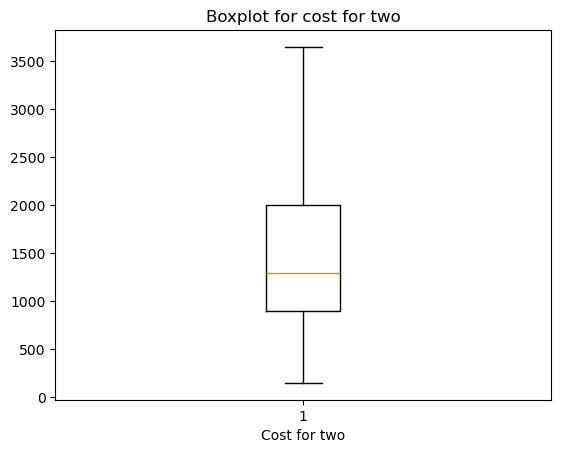

In [59]:
# Box plot
# Visualize the distribution and detect outliers in cost_for_two using a box plot

plt.boxplot(data['cost_for_two'])
plt.xlabel('Cost for two')
plt.title('Boxplot for cost for two')
plt.show()

The majority of restaurants are mid-range priced, while a small number of high-cost restaurants results in a right-skewed cost distribution.

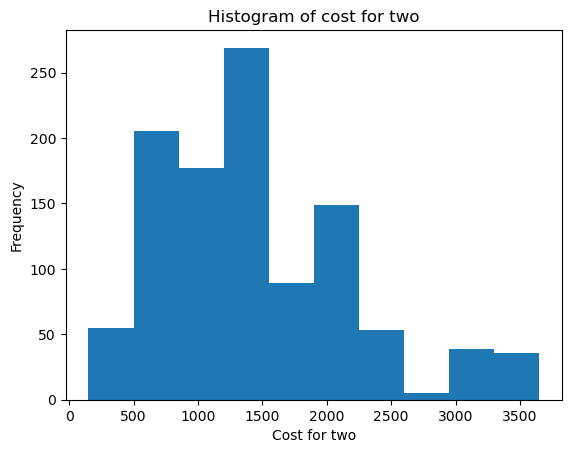

In [27]:
# Histogram
# Visualize the distribution of cost_for_two to understand frequency and skewness

plt.hist(data['cost_for_two'])
plt.xlabel('Cost for two')
plt.ylabel('Frequency')
plt.title('Histogram of cost for two')
plt.show()

The histogram shows that most restaurants are concentrated in the mid-range cost values, while fewer restaurants fall in the higher cost range, indicating a right-skewed distribution.

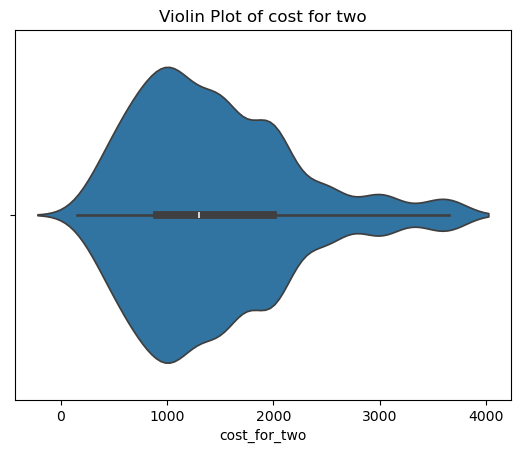

In [28]:
#Violin plot
# Visualize the distribution and density of cost_for_two using a violin plot

sns.violinplot(x=data['cost_for_two'])
plt.title('Violin Plot of cost for two')
plt.show()

The violin plot shows that most restaurants are concentrated in the mid-range cost values, with a wider density around the median and a longer right tail, indicating a right-skewed distribution with fewer high-cost restaurants.

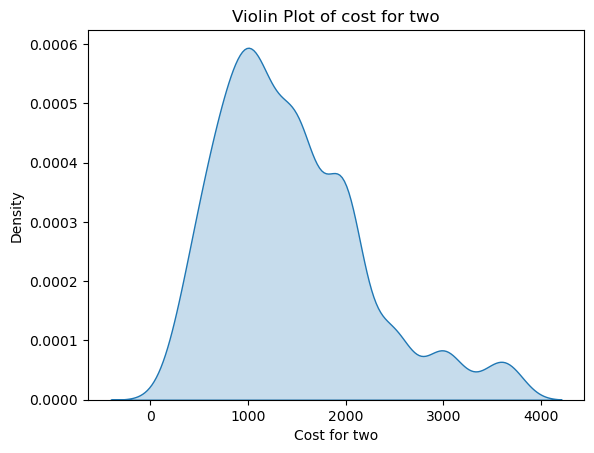

In [29]:
# KDE Plot 
# Visualize the probability density and skewness of cost_for_two using a KDE plot

sns.kdeplot(x=data['cost_for_two'], fill=True)
plt.xlabel('Cost for two')
plt.title('Violin Plot of cost for two')
plt.show()

The KDE plot shows a higher density around mid-range cost values and a gradual decline toward higher costs, indicating a right-skewed distribution with fewer high-priced restaurants.

## Analysis of Categorical Variables

In eazydinner dataset the categorical variables are
- city
- region
- cuisine
- cost_category

### Frequency Distribution

In [30]:
# Count the number of restaurants in each city

data['city'].value_counts()

city
Delhi NCR     90
Gurgaon       90
Noida         90
Chandigarh    90
Jaipur        90
Bangalore     90
Chennai       90
Hyderabad     90
Kochi         90
Coimbatore    90
Vizag         90
Faridabad     87
Name: count, dtype: int64

In [31]:
# Count the number of restaurants in each region

data['region'].value_counts()

region
South India    540
North India    537
Name: count, dtype: int64

In [32]:
# Count the frequency of each cuisine type

data['cuisine'].value_counts()

cuisine
Multicuisine                      445
Indian                             47
North Indian                       43
Cocktail Menu, Multicuisine        36
Cafe                               28
                                 ... 
Italian, North Indian, Chinese      1
Chaat                               1
Multicuisine, Cafe                  1
Italian, Pizza, Continental         1
Asian, Continental                  1
Name: count, Length: 200, dtype: int64

In [33]:
# Count the number of restaurants in each cost category

data['cost_category'].value_counts()

cost_category
Premium      518
Mid-range    326
Luxury       148
Budget        85
Name: count, dtype: int64

### Percentage Distribution

In [34]:
# Calculate the percentage distribution of restaurants across cities

data['city'].value_counts(normalize=True)*100

city
Delhi NCR     8.356546
Gurgaon       8.356546
Noida         8.356546
Chandigarh    8.356546
Jaipur        8.356546
Bangalore     8.356546
Chennai       8.356546
Hyderabad     8.356546
Kochi         8.356546
Coimbatore    8.356546
Vizag         8.356546
Faridabad     8.077994
Name: proportion, dtype: float64

In [35]:
# Calculate the percentage distribution of restaurants across regions

data['region'].value_counts(normalize=True)*100

region
South India    50.139276
North India    49.860724
Name: proportion, dtype: float64

In [36]:
# Calculate the percentage distribution of cuisines

data['cuisine'].value_counts(normalize=True)*100

cuisine
Multicuisine                      41.318477
Indian                             4.363974
North Indian                       3.992572
Cocktail Menu, Multicuisine        3.342618
Cafe                               2.599814
                                    ...    
Italian, North Indian, Chinese     0.092851
Chaat                              0.092851
Multicuisine, Cafe                 0.092851
Italian, Pizza, Continental        0.092851
Asian, Continental                 0.092851
Name: proportion, Length: 200, dtype: float64

In [37]:
# Calculate the percentage distribution of restaurants across cost categories

data['cost_category'].value_counts(normalize=True)*100

cost_category
Premium      48.096565
Mid-range    30.269266
Luxury       13.741876
Budget        7.892293
Name: proportion, dtype: float64

### Visualization of Categorical Variables

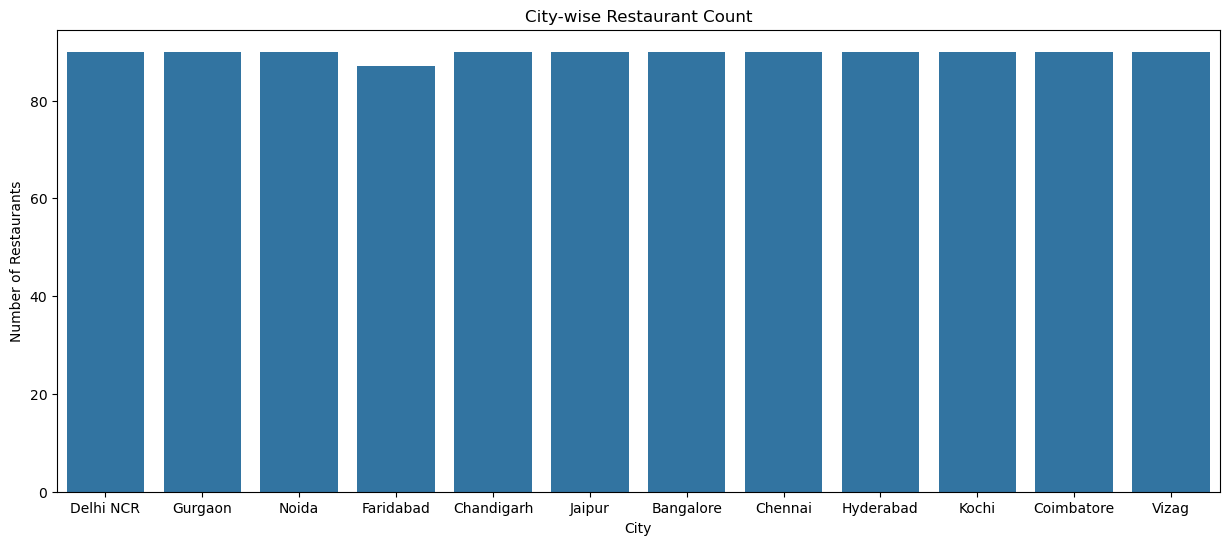

In [38]:
# Countplot
# Visualize the number of restaurants across different cities

plt.figure(figsize=(15,6))
sns.countplot(x='city', data=data)
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.title('City-wise Restaurant Count')
plt.show()

The count plot shows that restaurants are fairly evenly distributed across cities, with no single city overwhelmingly dominating the dataset. This indicates balanced city-wise representation in the data.

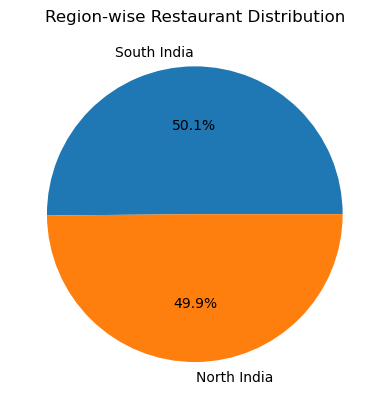

In [39]:
# Piechart
# Visualize the percentage distribution of restaurants across regions using a pie chart

region_counts = data['region'].value_counts()
plt.pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%')
plt.title("Region-wise Restaurant Distribution")
plt.show()

Restaurants are almost evenly distributed between North and South India, with a slight dominance of South India.

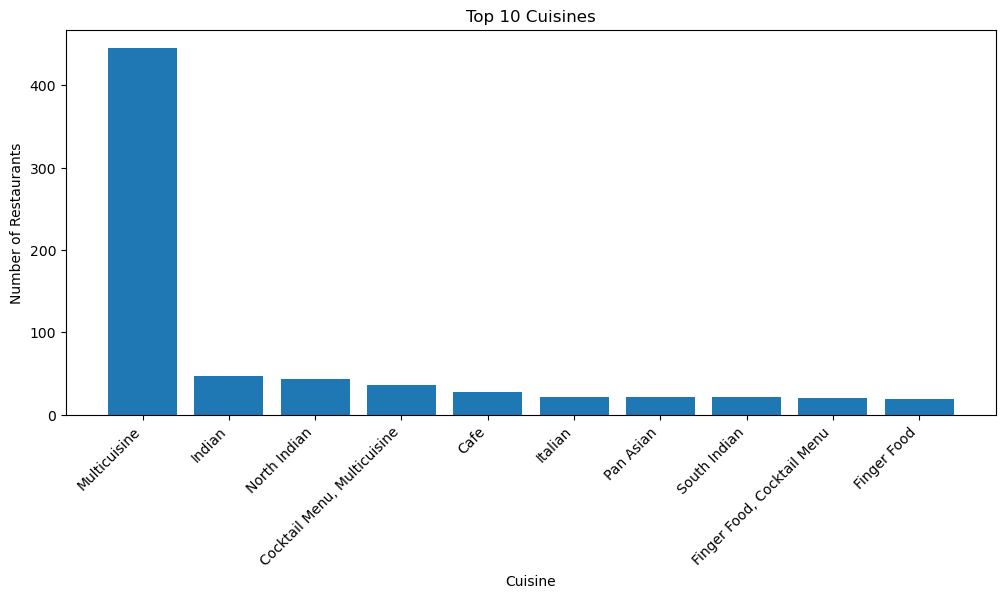

In [40]:
# Barplot
# Visualize the top 10 most common cuisines based on restaurant count

plt.figure(figsize=(12,5))
top_cuisines= data['cuisine'].value_counts().head(10)
plt.bar(top_cuisines.index, top_cuisines.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.title('Top 10 Cuisines')
plt.show()

Multicuisine restaurants dominate the dataset, while other cuisines have significantly fewer restaurants, indicating diverse but uneven cuisine representation.

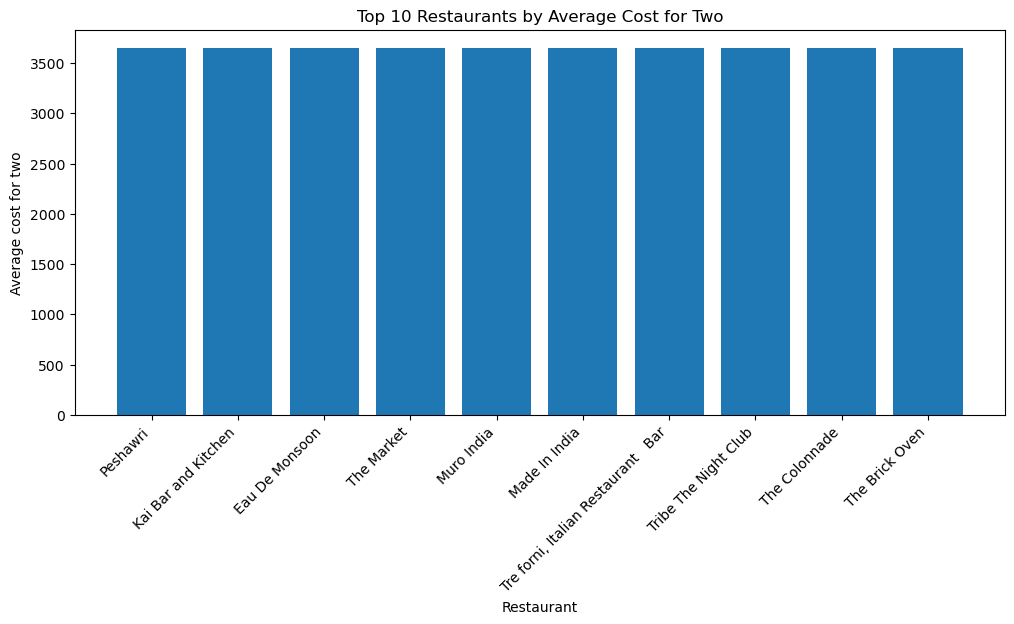

In [41]:
# Barplot
# Visualize average cost for two for top 10 most expensive restaurants

top_cost_restaurants = (data.groupby('restaurant_name')['cost_for_two'].mean().sort_values(ascending=False).head(10))

plt.figure(figsize=(12,5))
plt.bar(top_cost_restaurants.index, top_cost_restaurants.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Restaurant')
plt.ylabel('Average cost for two')
plt.title('Top 10 Restaurants by Average Cost for Two')
plt.show()
            

The bar chart shows that these restaurants have the highest average cost for two, indicating premium or luxury dining options with similar pricing levels across the top restaurants.

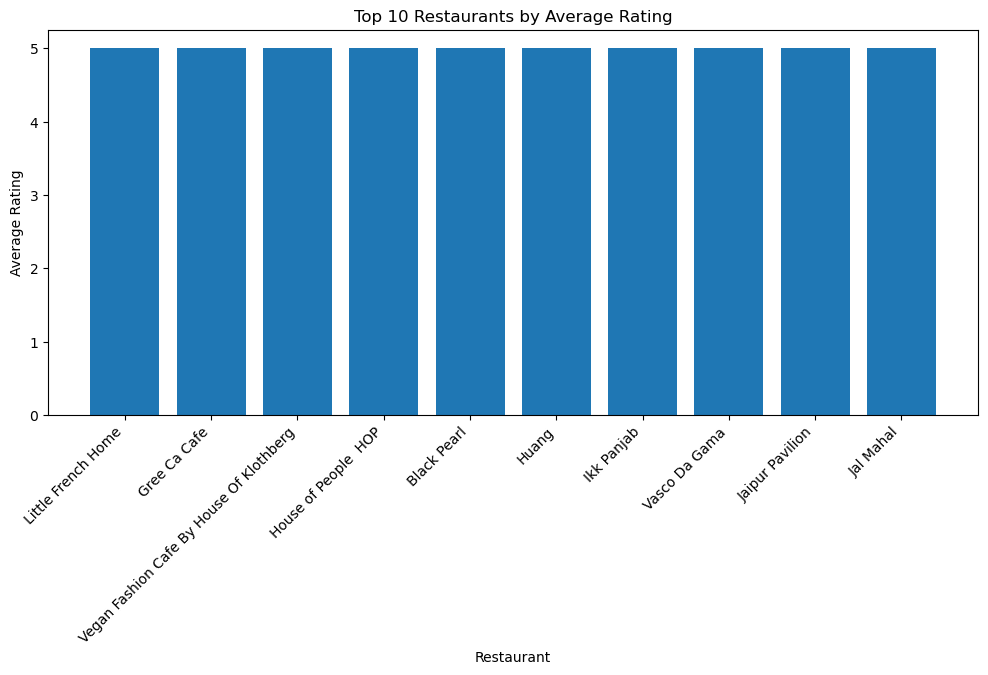

In [42]:
# Barplot
# Visualize average rating for top 10 highest-rated restaurants

top_rated_restaurants = (data.groupby('restaurant_name')['rating'].mean().sort_values(ascending=False).head(10))

plt.figure(figsize=(12,5))
plt.bar(top_rated_restaurants.index, top_rated_restaurants.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Restaurant')
plt.ylabel('Average Rating')
plt.title('Top 10 Restaurants by Average Rating')
plt.show()


The bar chart shows that the top-rated restaurants have consistently high average ratings, indicating strong and uniform customer satisfaction among these establishments.

## Bi-variate / Multivariate Anlysis

### Continuous  and Categorical variables (groupby, pivot table)  
- GroupBy and pivot tables were used to analyze cost and rating variations across cities and regions.

In [43]:
# Calculate the average cost for two across different cities

data.groupby('city')['cost_for_two'].mean()

city
Bangalore     2022.222222
Chandigarh    1353.888889
Chennai       1442.500000
Coimbatore    1057.222222
Delhi NCR     1913.377778
Faridabad     1206.896552
Gurgaon       1616.111111
Hyderabad     1463.333333
Jaipur        1405.555556
Kochi         1284.200000
Noida         1326.111111
Vizag         1143.888889
Name: cost_for_two, dtype: float64

In [44]:
# Calculate the average rating by city to compare customer satisfaction

data.groupby('city')['rating'].mean()

city
Bangalore     4.256667
Chandigarh    4.068889
Chennai       4.225556
Coimbatore    4.203333
Delhi NCR     4.123333
Faridabad     4.087356
Gurgaon       4.291111
Hyderabad     4.108889
Jaipur        4.316667
Kochi         4.317778
Noida         4.061111
Vizag         4.185556
Name: rating, dtype: float64

In [45]:
# Calculate the number of restaurants in each city

data.groupby('city').size()

city
Bangalore     90
Chandigarh    90
Chennai       90
Coimbatore    90
Delhi NCR     90
Faridabad     87
Gurgaon       90
Hyderabad     90
Jaipur        90
Kochi         90
Noida         90
Vizag         90
dtype: int64

In [46]:
# Calculate city-wise summary statistics for cost_for_two

data.groupby('city')['cost_for_two'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
city,,,,
Bangalore,2022.222222,2000.0,400.0,3650.0
Chandigarh,1353.888889,1400.0,300.0,3500.0
Chennai,1442.500000,1200.0,400.0,3650.0
Coimbatore,1057.222222,1000.0,150.0,2400.0
Delhi NCR,1913.377778,1800.0,400.0,3650.0
Faridabad,1206.896552,1000.0,200.0,3650.0
Gurgaon,1616.111111,1500.0,600.0,3650.0
Hyderabad,1463.333333,1200.0,300.0,3650.0
Jaipur,1405.555556,1200.0,500.0,3650.0


The table summarizes city-wise cost patterns, showing typical dining costs as well as the price range across different cities.

In [47]:
# Calculate the average cost_for_two by region and city

data.groupby(['region','city'])['cost_for_two'].mean()

region       city      
North India  Chandigarh    1353.888889
             Delhi NCR     1913.377778
             Faridabad     1206.896552
             Gurgaon       1616.111111
             Jaipur        1405.555556
             Noida         1326.111111
South India  Bangalore     2022.222222
             Chennai       1442.500000
             Coimbatore    1057.222222
             Hyderabad     1463.333333
             Kochi         1284.200000
             Vizag         1143.888889
Name: cost_for_two, dtype: float64

The results show how average dining costs vary across cities within each region.

In [48]:
# Create a pivot table to calculate the average cost_for_two by region

pd.pivot_table(data, values='cost_for_two', index='region', aggfunc='mean')

,cost_for_two
region,
North India,1471.795158
South India,1402.227778


The pivot table highlights regional differences in average dining costs.

In [49]:
# Create a pivot table to compare average cost_for_two across cities and regions

pd.pivot_table(data, values='cost_for_two', index='city', columns='region', aggfunc='mean')

region,North India,South India
city,,
Bangalore,NaN,2022.222222
Chandigarh,1353.888889,NaN
Chennai,NaN,1442.500000
Coimbatore,NaN,1057.222222
Delhi NCR,1913.377778,NaN
Faridabad,1206.896552,NaN
Gurgaon,1616.111111,NaN
Hyderabad,NaN,1463.333333
Jaipur,1405.555556,NaN


The table compares average dining costs across cities within each region, highlighting regional pricing variations.

In [50]:
# Create a pivot table to calculate the average restaurant rating by region

pd.pivot_table(data, values='rating', index='region', aggfunc='mean')

,rating
region,
North India,4.158473
South India,4.216296


The pivot table shows regional differences in average customer ratings.

### Continuous  to Continuous variable  (correlation plot) 


In [51]:
# Calculate the correlation between cost_for_two and rating

data[['cost_for_two','rating']].corr()

,cost_for_two,rating
cost_for_two,1.000000,0.045813
rating,0.045813,1.000000


The correlation between cost for two and rating is very weak and positive (0.036), indicating that higher-priced restaurants do not necessarily receive higher customer ratings.

### Heatmap

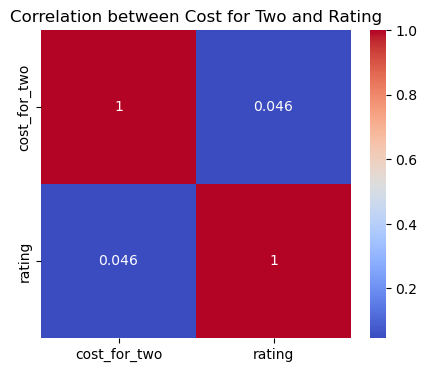

In [52]:
# Visualize the correlation between cost_for_two and rating using a heatmap

corr_matrix = data[['cost_for_two', 'rating']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation between Cost for Two and Rating')
plt.show()

The heatmap shows a very weak positive correlation between cost for two and rating, indicating that higher-priced restaurants do not necessarily have higher customer ratings.

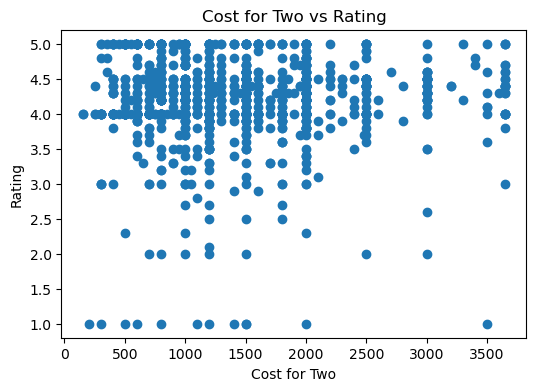

In [53]:
## Scatter plot

# Visualize the relationship between cost_for_two and rating to identify trends and outliers

plt.figure(figsize=(6,4))
plt.scatter(data['cost_for_two'], data['rating'])
plt.xlabel('Cost for Two')
plt.ylabel('Rating')
plt.title('Cost for Two vs Rating')
plt.show()

The scatter plot shows no clear relationship between cost and rating, with ratings spread across all cost levels, indicating that higher-priced restaurants do not necessarily receive higher ratings.

### Categorical to Categorical variables  (crosstab) 


In [54]:
# Create a cross-tabulation to show how cities are distributed across regions

pd.crosstab(data['city'], data['region'])

region,North India,South India
city,,
Bangalore,0,90
Chandigarh,90,0
Chennai,0,90
Coimbatore,0,90
Delhi NCR,90,0
Faridabad,87,0
Gurgaon,90,0
Hyderabad,0,90
Jaipur,90,0


The table shows the regional classification of cities, indicating which cities belong to each region.

In [55]:
# Create a cross-tabulation to show cuisine distribution across regions

pd.crosstab(data['cuisine'], data['region'])

region,North India,South India
cuisine,,
500 for two,1,0
600 for two,1,0
"African, Portuguese",1,0
American,2,3
Andhra,0,1
...,...,...
"Thai, Cantonese",0,1
"Thai, Chinese",0,1
Turkish,0,1


The table highlights how different cuisines are distributed across regions, reflecting regional food preferences.

In [56]:
# Create a cross-tabulation to show cost category distribution across cities

pd.crosstab(data['city'], data['cost_category'])

cost_category,Budget,Mid-range,Premium,Luxury
city,,,,
Bangalore,5,4,60,21
Chandigarh,7,26,47,10
Chennai,7,30,37,16
Coimbatore,13,44,30,3
Delhi NCR,2,13,46,29
Faridabad,14,30,33,10
Gurgaon,0,17,61,12
Hyderabad,2,29,45,14
Jaipur,1,36,44,9


The table shows how budget, mid-range, and premium restaurants are distributed across different cities.

In [57]:
# Create a percentage cross-tabulation of cost categories across regions

pd.crosstab(data['region'], data['cost_category'], normalize='index') * 100

cost_category,Budget,Mid-range,Premium,Luxury
region,,,,
North India,6.890130,25.884544,52.886406,14.338920
South India,8.888889,34.629630,43.333333,13.148148


The table shows the percentage distribution of cost categories within each region, enabling easy comparison across regions.

In [58]:
# Crosstab with Margins (Totals)
# Create a cross-tabulation with totals to show city and region distribution

pd.crosstab(data['city'], data['region'], margins=True)

region,North India,South India,All
city,,,
Bangalore,0,90,90
Chandigarh,90,0,90
Chennai,0,90,90
Coimbatore,0,90,90
Delhi NCR,90,0,90
Faridabad,87,0,87
Gurgaon,90,0,90
Hyderabad,0,90,90
Jaipur,90,0,90


The table includes total counts for cities and regions, providing an overall summary of restaurant distribution.

## Final Conclusion
### 🔹 Distribution Insight

- Restaurant data from EazyDiner shows a balanced distribution across cities and regions.

- City-wise and region-wise comparisons show balanced restaurant representation.

- South and North India exhibit comparable restaurant presence.

### 🔹 Pricing Insight

- Most restaurants fall into the mid-range cost category, indicating general affordability.

- A few high-cost restaurants create right-skewness in the cost distribution.

- Regional analysis shows similar pricing trends with minor variations.

- High-cost outliers were identified and treated using IQR-based capping.

### 🔹 Rating & Satisfaction Insight

- Customer ratings remain consistent across cost levels, showing price has limited influence.

- Correlation analysis confirms a very weak relationship between cost and rating.

- Rating patterns are similar across cities and regions.

### 🔹 Cuisine Preference Insight

- Multi-cuisine restaurants dominate, reflecting diverse customer food preferences.

### 🔹 Overall Inference

- Overall, the analysis provides useful insights into pricing trends, cuisine popularity, and customer behavior.

### Recommendations:

- Mid-range pricing performs well across cities
- Improving service quality may impact ratings more than pricing
- Multi-cuisine restaurants attract broader audiences

### Limitations: 
- Analysis is based on scraped data from a single platform  
- Ratings are subjective and user-driven 

In [60]:
data

,restaurant_name,city,location,cuisine,cost_for_two,rating,restaurant_url,region,city_region,primary_cuisine,secondary_cuisine,cost_category
0,Desi Villagio,Delhi NCR,"Connaught Place CP , Central Delhi",Indian,1300.0,4.1,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India,Indian,None,Premium
1,Cafe Out of the Box Courtyard,Delhi NCR,"Connaught Place CP , Central Delhi",Multicuisine,1200.0,3.9,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India,Multicuisine,None,Premium
2,Hard Rock Cafe,Delhi NCR,"Connaught Place CP , Central Delhi",Multicuisine,1500.0,4.0,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India,Multicuisine,None,Premium
3,Sakura,Delhi NCR,"The Metropolitan Hotel Spa, New Delhi","Japanese, Sushi",3650.0,4.0,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India,Japanese,Sushi,Luxury
4,Dr Zombie,Delhi NCR,"Connaught Place CP , Central Delhi","Italian, Cocktail Menu",1000.0,4.3,https://www.eazydiner.comhttps://www.eazydiner...,North India,Delhi NCR - North India,Italian,Cocktail Menu,Mid-range
...,...,...,...,...,...,...,...,...,...,...,...,...
1072,District 12,Vizag,"Kirlampudi Layout, Visakhapatnam",Pan Asian,500.0,4.5,https://www.eazydiner.comhttps://www.eazydiner...,South India,Vizag - South India,Pan Asian,None,Budget
1073,Four Corners Mantris Hotel,Vizag,"Asilmetta, Visakhapatnam","Chinese, Indian",700.0,4.1,https://www.eazydiner.comhttps://www.eazydiner...,South India,Vizag - South India,Chinese,Indian,Mid-range
1074,Tap The Sports Bar,Vizag,"Maharani Peta, Visakhapatnam","Finger Food, Cocktail Menu",1900.0,4.7,https://www.eazydiner.comhttps://www.eazydiner...,South India,Vizag - South India,Finger Food,Cocktail Menu,Premium
1075,FULL Moon,Vizag,"The Bheemli Resort, Visakhapatnam",Multicuisine,2500.0,4.0,https://www.eazydiner.comhttps://www.eazydiner...,South India,Vizag - South India,Multicuisine,None,Luxury
